# [기초-실습] 통계 101x데이터 분석: (5-6장) 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 2.8 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.6 MB 5.3 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.6 MB 5.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 5.8 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 6.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 6.4 MB/s eta 0:00:01
   ------------------------------- -------- 7.6/9.6 MB 5.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.0 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   --

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [2]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [38]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 이항검정을 수행하여 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"만약 개발사의 주장대로 실제 확률이 정말 10%라면"** 200번 뽑기에서 성공 횟수가 어떻게 분포하는지 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 우리가 관찰한 '12번 성공'이 얼마나 희귀한 일인지 관찰해 봅시다.

In [ ]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): p = 0.10  (개발사 주장대로 10%)
# H₁ (대립가설): p < 0.10  (실제 확률이 10%보다 낮다)

In [39]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?
result = stats.binomtest(x, n, p, alternative='less')
p_value = result.pvalue

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")
print(f"p-value: {p_value:.4f}")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)
p-value: 0.0320


In [40]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print(f"p-value({p_value:.4f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 실제 확률이 10%보다 낮다고 볼 만한 유의미한 증거가 있다.")
else:
    print(f"p-value({p_value:.4f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 10%보다 낮다고 단정할 만한 증거는 부족하다.")

p-value(0.0320) < 유의수준(0.05) → 귀무가설 기각
→ 실제 확률이 10%보다 낮다고 볼 만한 유의미한 증거가 있다.


In [41]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.
np.random.seed(42)
n_simulations = 10000
simulated_successes = np.random.binomial(n=n, p=p, size=n_simulations)

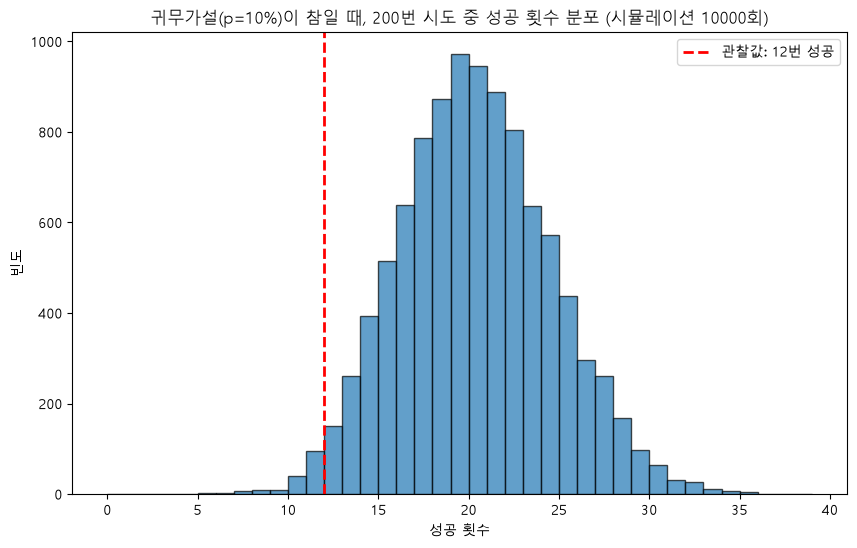

In [42]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.
plt.figure(figsize=(10, 6))
plt.hist(simulated_successes, bins=range(0, 40), edgecolor='black', alpha=0.7)
plt.axvline(x=x, color='red', linestyle='--', linewidth=2, label=f'관찰값: {x}번 성공')
plt.title(f'귀무가설(p=10%)이 참일 때, {n}번 시도 중 성공 횟수 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('성공 횟수')
plt.ylabel('빈도')
plt.legend()
plt.show()

In [43]:
from scipy import stats

# 임계값 계산 (단측검정, 왼쪽 꼬리 기준)
# 유의수준 0.05에서 귀무가설을 기각하게 되는 성공 횟수의 경계값
critical_value = stats.binom.ppf(0.05, n, p)
print(f"임계값(critical value): {critical_value}")

# ppf는 누적확률이 0.05 '이상'이 되는 가장 작은 x를 반환하므로,
# 실제 기각역(누적확률 <= 0.05)은 그보다 1 작은 값부터 시작하는 경우가 많음 -> 확인
for k in range(0, 20):
    cdf_k = stats.binom.cdf(k, n, p)
    print(f"P(X <= {k}) = {cdf_k:.4f}")

임계값(critical value): 13.0
P(X <= 0) = 0.0000
P(X <= 1) = 0.0000
P(X <= 2) = 0.0000
P(X <= 3) = 0.0000
P(X <= 4) = 0.0000
P(X <= 5) = 0.0000
P(X <= 6) = 0.0001
P(X <= 7) = 0.0005
P(X <= 8) = 0.0014
P(X <= 9) = 0.0035
P(X <= 10) = 0.0081
P(X <= 11) = 0.0168
P(X <= 12) = 0.0320
P(X <= 13) = 0.0566
P(X <= 14) = 0.0929
P(X <= 15) = 0.1431
P(X <= 16) = 0.2075
P(X <= 17) = 0.2849
P(X <= 18) = 0.3724
P(X <= 19) = 0.4655


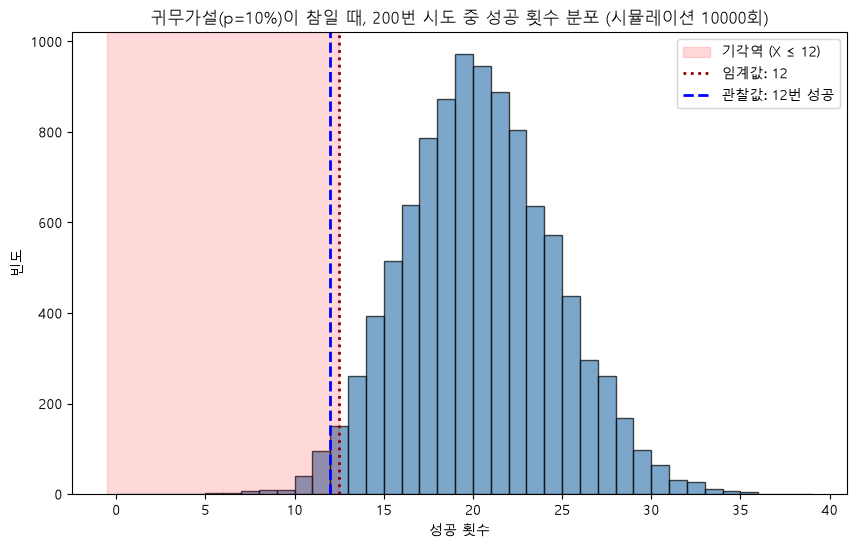

In [44]:
# 위 출력에서 P(X<=k) <= 0.05를 만족하는 가장 큰 k를 기각역 경계로 사용
critical_k = 12  # 출력 결과 보고 실제 값으로 교체

plt.figure(figsize=(10, 6))
plt.hist(simulated_successes, bins=range(0, 40), edgecolor='black', alpha=0.7, color='steelblue')

# 기각역(임계값 이하) 음영 표시
plt.axvspan(-0.5, critical_k + 0.5, color='red', alpha=0.15, label=f'기각역 (X ≤ {critical_k})')

# 임계값 경계선
plt.axvline(x=critical_k + 0.5, color='darkred', linestyle=':', linewidth=2, label=f'임계값: {critical_k}')

# 관찰값 표시
plt.axvline(x=x, color='blue', linestyle='--', linewidth=2, label=f'관찰값: {x}번 성공')

plt.title(f'귀무가설(p=10%)이 참일 때, {n}번 시도 중 성공 횟수 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('성공 횟수')
plt.ylabel('빈도')
plt.legend()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요? -> 기각영역에 속한다

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요? -> 드문일이다, 즉 귀무가설을 기각해야한다.

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요? 

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요? -> 더 희귀한 케이스이기때문에 p값이 더 작아질 것이고, 따라서 귀무가설을 반증하는 정도가 더 커져서 더 강력하게 귀무가설을 기각할 것이다. 하지만 결론(대립가설을 채택함)은 같음

In [45]:
# 문제 설정_추가
n = 1000  # 총 시행 횟수
x = 60   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 1000번 시도 중 60번 성공 (관찰 성공률 6.0%)


관찰 결과: 1000번 시도 중 60번 성공 (관찰 성공률 6.0%)
p-value: 0.00000438
p-value(0.0000) < 유의수준(0.05) → 귀무가설 기각
→ 실제 확률이 10%보다 낮다고 볼 만한 유의미한 증거가 있다.


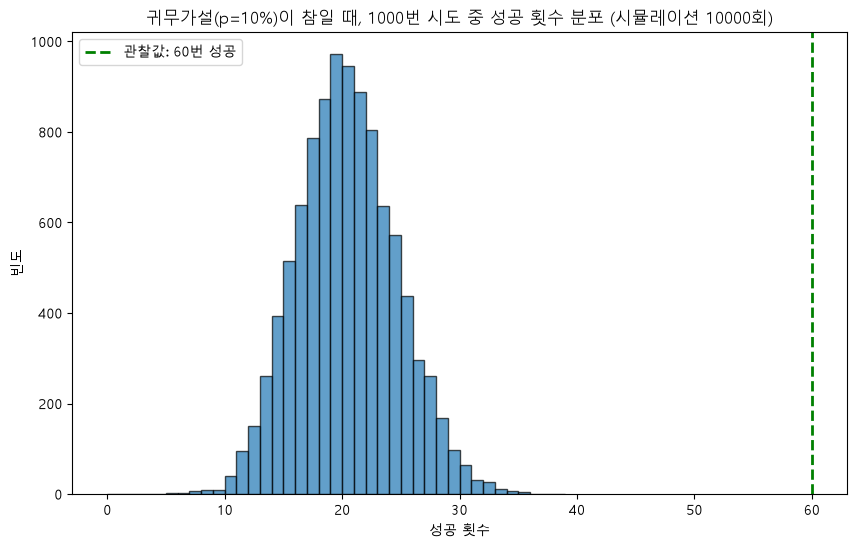

In [46]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?
result = stats.binomtest(x, n, p, alternative='less')
p_value = result.pvalue

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")
print(f"p-value: {p_value:.8f}")

alpha = 0.05
if p_value < alpha:
    print(f"p-value({p_value:.4f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 실제 확률이 10%보다 낮다고 볼 만한 유의미한 증거가 있다.")
else:
    print(f"p-value({p_value:.4f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 10%보다 낮다고 단정할 만한 증거는 부족하다.")

plt.figure(figsize=(10, 6))
plt.hist(simulated_successes, bins=range(0, 40), edgecolor='black', alpha=0.7)
plt.axvline(x=x, color='green', linestyle='--', linewidth=2, label=f'관찰값: {x}번 성공')
plt.title(f'귀무가설(p=10%)이 참일 때, {n}번 시도 중 성공 횟수 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('성공 횟수')
plt.ylabel('빈도')
plt.legend()
plt.show()

In [ ]:
# [문제 1] 데이터를 어떻게 읽을까요?

[1번문제]
- p-값(0.032)은 히스토그램에서 기각영역(빨간 음영, X ≤ 12) 부분의 넓이(비율)에 해당한다. 즉, "귀무가설(p=10%)이 참이라고 가정했을 때, 200번 중 12번 이하로 성공할 확률"을 뜻하며, 그래프 왼쪽 꼬리의 누적 면적으로 나타난다.

[2번문제]
- 드문 일이다. 히스토그램을 보면 12는 분포의 중심(약 20 근처)에서 크게 벗어나 있고, 기각영역 안에 위치한다. 즉 개발사의 주장(10%)이 맞다면 좀처럼 나오기 힘든 결과이므로, 귀무가설을 기각하고 실제 확률이 10%보다 낮다고 판단한다.

[3번문제]
- p-값은 '만약 정말 공정한 동전이라면, 이런 결과(또는 더 극단적인 결과)가 나올 확률이 얼마나 되는지'를 숫자로 알려주는 거야. 그 확률이 너무 작으면(예: 5% 미만) '그건 우연이라기엔 너무 희귀해. 동전이 이상한 게 맞나 보다'라고 결론 내리는 거고. 그게 바로 귀무가설(=공정한 동전)을 기각하는 거야.

[4번문제]
- 표본 크기가 커지면 같은 6%라도 p-값은 훨씬 더 작아진다. 표본이 클수록 우연에 의한 변동 폭(표준오차)이 줄어들기 때문에, 진짜 확률이 10%라면 6%라는 결과가 나올 여지가 더욱 희박해지기 때문이다. 따라서 귀무가설을 기각하는 근거가 더 강력해지지만, 결론(대립가설 채택 = 10%보다 낮다) 자체는 200번일 때와 동일하다. 즉, 표본 크기는 결론의 '강도'를 바꾸지, 결론의 '방향'을 바꾸지는 않는다.

# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

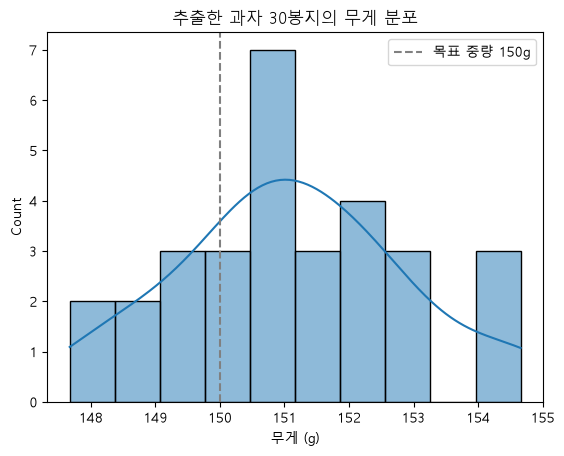

In [13]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [ ]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 표본 평균 = 150g (공정이 목표 중량을 잘 맞추고 있다)
# H₁ (대립가설): 표본 평균 ≠ 150g (공정이 목표 중량과 유의미하게 다르다)

In [14]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
t_stat, p_value = stats.ttest_1samp(sample_weights, pop_mean)
print(f"표본 평균: {sample_weights.mean():.4f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

표본 평균: 151.1237
t-통계량: 3.4193
p-value: 0.0019


In [15]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print(f"\np-value({p_value:.4f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 표본 평균이 150g과 유의미하게 다르다.")
else:
    print(f"\np-value({p_value:.4f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 표본 평균이 150g과 유의미하게 다르다고 볼 증거가 부족하다.")


p-value(0.0019) < 유의수준(0.05) → 귀무가설 기각
→ 표본 평균이 150g과 유의미하게 다르다.


In [16]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.
np.random.seed(42)
n_simulations = 10000
sample_size = 30
sample_std = sample_weights.std(ddof=1)  # 표본표준편차 사용

simulated_means = []
for _ in range(n_simulations):
    sim_sample = np.random.normal(loc=pop_mean, scale=sample_std, size=sample_size)
    simulated_means.append(sim_sample.mean())

simulated_means = np.array(simulated_means)

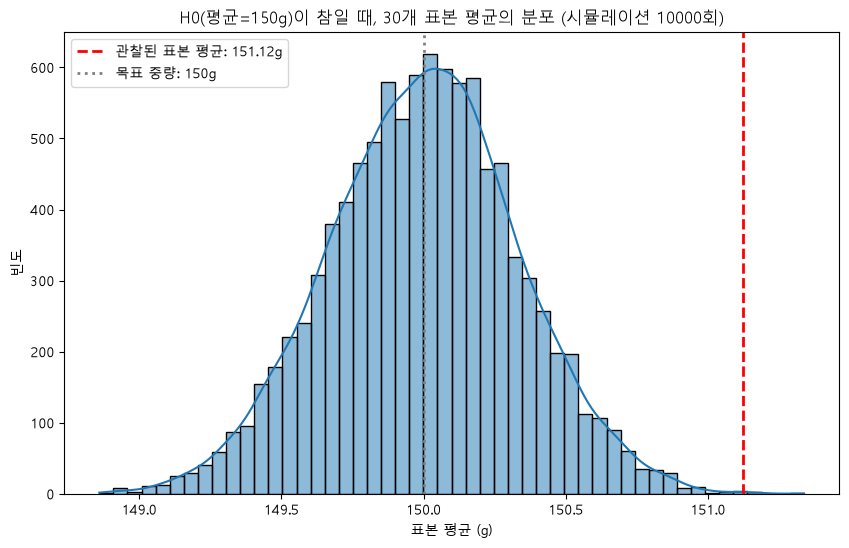

In [17]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.
observed_mean = sample_weights.mean()

plt.figure(figsize=(10, 6))
sns.histplot(simulated_means, bins=50, kde=True)
plt.axvline(x=observed_mean, color='red', linestyle='--', linewidth=2, 
            label=f'관찰된 표본 평균: {observed_mean:.2f}g')
plt.axvline(x=pop_mean, color='gray', linestyle=':', linewidth=2, 
            label=f'목표 중량: {pop_mean}g')
plt.title(f'H0(평균=150g)이 참일 때, 30개 표본 평균의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('표본 평균 (g)')
plt.ylabel('빈도')
plt.legend()
plt.show()

하한 임계값: 149.3398g
상한 임계값: 150.6579g


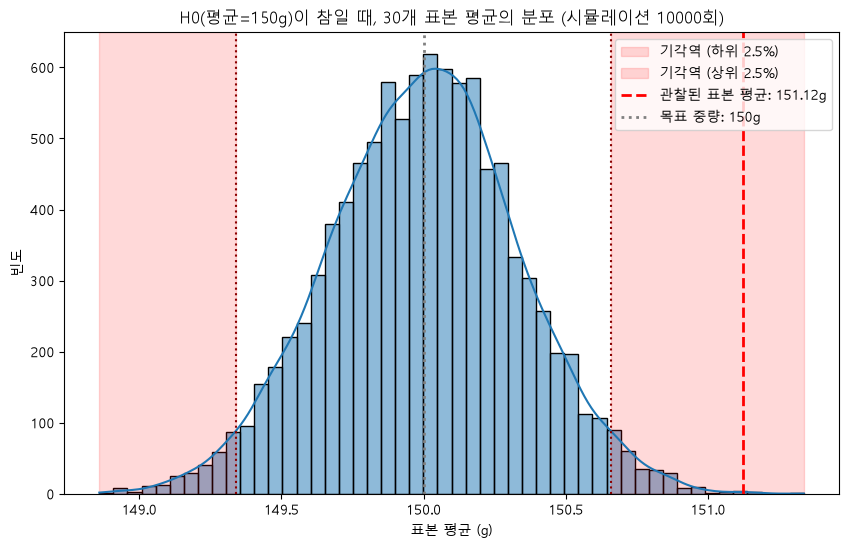


관찰된 표본 평균(151.12g)이 기각역 안에 속함


In [18]:
# 기각역 계산 (양측검정, alpha=0.05 -> 양쪽 각각 2.5%)
alpha = 0.05
lower_critical = np.percentile(simulated_means, 100 * (alpha/2))
upper_critical = np.percentile(simulated_means, 100 * (1 - alpha/2))

print(f"하한 임계값: {lower_critical:.4f}g")
print(f"상한 임계값: {upper_critical:.4f}g")

plt.figure(figsize=(10, 6))
sns.histplot(simulated_means, bins=50, kde=True)

# 기각역 음영 표시
plt.axvspan(simulated_means.min(), lower_critical, color='red', alpha=0.15, label='기각역 (하위 2.5%)')
plt.axvspan(upper_critical, simulated_means.max(), color='red', alpha=0.15, label='기각역 (상위 2.5%)')

# 임계값 경계선
plt.axvline(x=lower_critical, color='darkred', linestyle=':', linewidth=1.5)
plt.axvline(x=upper_critical, color='darkred', linestyle=':', linewidth=1.5)

# 관찰값 & 목표중량
plt.axvline(x=observed_mean, color='red', linestyle='--', linewidth=2, 
            label=f'관찰된 표본 평균: {observed_mean:.2f}g')
plt.axvline(x=pop_mean, color='gray', linestyle=':', linewidth=2, 
            label=f'목표 중량: {pop_mean}g')

plt.title(f'H0(평균=150g)이 참일 때, 30개 표본 평균의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('표본 평균 (g)')
plt.ylabel('빈도')
plt.legend()
plt.show()

print(f"\n관찰된 표본 평균({observed_mean:.2f}g)이 기각역 안에 "
      f"{'속함' if observed_mean <= lower_critical or observed_mean >= upper_critical else '속하지 않음'}")

**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리) -> 표본의 크기가 30개로 꽤 크기 때문

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요? -> 엄청 희귀한 경우이다, 검정통계량의 값이 x축의 끝에(말단에) 위치해있을 것이고, 따라서 그 영역의 크기도 작을것이다=p값이 작다

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요? 이번 가설검정에서의 p값은 0.0019로 나옴. 0.001이라면 더 작아지는 것이므로 세로선이 더 오른쪽으로 치우칠 것이다.

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?) -> 어떤 부품의 무게가 계획했던것과 안맞는지(무거운지) 조사해보고, 이를 해결해서 중량을 줄여야할 것이다. 아니면 애초에 충량 평균을 잘못잡았을수도 있으니, 평균자체를 조정해야한다.(아예 공정의 설계도? 자체를 바꿈)

In [ ]:
# [문제 2] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

[1번 문제]
- 이 분포가 종 모양의 정규분포를 따르는 이유는 중심극한정리(CLT) 때문이다. 원래 개별 데이터가 정규분포든 아니든, 표본 크기가 충분히 크면(n>=30) 표본 평균들의 분포는 정규분포에 가까워진다. n=30은 CLT가 잘 적용되는 대표적인 기준치라서, 지금처럼 매끈한 종 모양이 나온 것이다.

[2번 문제]
- 엄청 희귀한 값이다. 그래프에서 관찰된 표본 평균(151.12g)은 분포의 오른쪽 끝, 기각역 바깥쪽에 위치해 있다. 즉 귀무가설이 맞다면 거의 나오기 힘든 극단적인 값이라는 뜻이다.

- 이건 p-값과 직접 연결된다. p-값은 "이 값 또는 그보다 더 극단적인 값이 나올 확률"이므로, 그래프 상에서 관찰값보다 바깥쪽(꼬리 방향)에 해당하는 면적의 비율과 같다. 관찰값이 분포의 중심에서 멀리 떨어져 꼬리 쪽 끝단에 위치할수록 그 바깥 면적은 작아지고, 그만큼 p-값도 작아진다. 지금처럼 세로선이 분포 끝에 걸쳐 있으면 p-값이 작다(0.0019)는 게 시각적으로도 확인된다.

[3번 문제]
- 이번 검정의 p-값은 0.0019인데, 0.001은 이보다 더 작은 값이다. p-값이 작을수록 "귀무가설 하에서 나오기 더 어려운 극단적인 값"이라는 뜻이므로, 세로선은 지금보다 분포 중심(150g)에서 더 멀리, 오른쪽 꼬리 끝 쪽으로 더 치우친 위치에 있을 것이다. 즉 관찰된 표본 평균이 151.12g보다 더 크게 나왔을 경우에 해당한다.

[4번 문제]
- 통계적으로 표본 평균(151.12g)이 목표 중량(150g)보다 유의미하게 무겁다는 결론이 나왔으므로, 공정이 목표치를 정확히 맞추지 못하고 있다는 신호다. 공장은 두 가지 방향으로 대응할 수 있다.

1) 어떤 투입 재료나 공정 단계에서 과다 충전이 일어나고 있는지 원인을 조사하고 조정해서 평균 중량을 150g에 맞게 낮춰야 한다.
2) 둘째, 만약 원인 조사 결과 현재 151g대가 오히려 더 안정적인 공정값이라면, 애초에 목표 중량 설정 자체나 설비 세팅값을 재검토해야 한다. (하지만, 경제적으로 봤을 때 무게가 목표보다 계속 무겁게 나오는 것은 원가 손실을 의미하기 때문에 신중하게 결정해야할 것이다.)

# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

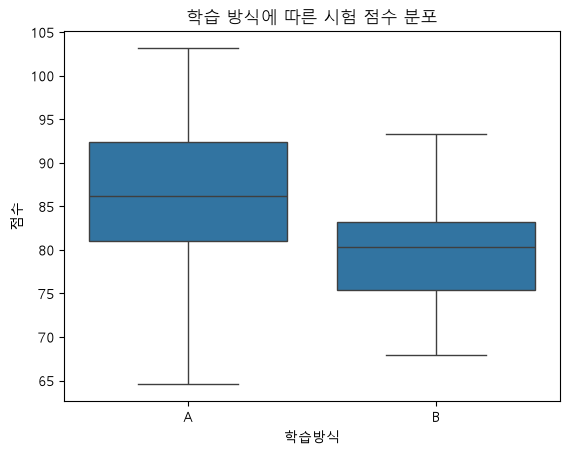

In [19]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [21]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.
shapiro_a = stats.shapiro(group_a_scores)
shapiro_b = stats.shapiro(group_b_scores)

print("=== 정규성 검정 (Shapiro-Wilk) ===")
print(f"A그룹: 통계량={shapiro_a.statistic:.4f}, p-value={shapiro_a.pvalue:.4f}")
print(f"B그룹: 통계량={shapiro_b.statistic:.4f}, p-value={shapiro_b.pvalue:.4f}")

alpha = 0.05
print(f"A그룹 정규성: {'정규분포 따름 (기각 못함)' if shapiro_a.pvalue >= alpha else '정규분포 아님 (기각)'}")
print(f"B그룹 정규성: {'정규분포 따름 (기각 못함)' if shapiro_b.pvalue >= alpha else '정규분포 아님 (기각)'}")

=== 정규성 검정 (Shapiro-Wilk) ===
A그룹: 통계량=0.9876, p-value=0.8766
B그룹: 통계량=0.9866, p-value=0.8366
A그룹 정규성: 정규분포 따름 (기각 못함)
B그룹 정규성: 정규분포 따름 (기각 못함)


In [22]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.
levene_result = stats.levene(group_a_scores, group_b_scores)
print("=== 등분산성 검정 (Levene) ===")
print(f"통계량={levene_result.statistic:.4f}, p-value={levene_result.pvalue:.4f}")

equal_var = levene_result.pvalue >= alpha
print(f"등분산 가정: {'만족함 (equal_var=True)' if equal_var else '만족 안 함 (equal_var=False)'}")

=== 등분산성 검정 (Levene) ===
통계량=6.1330, p-value=0.0150
등분산 가정: 만족 안 함 (equal_var=False)


In [23]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.
t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=False)

print("=== 이표본 t-검정 (Welch's t-test) ===")
print(f"A그룹 평균: {group_a_scores.mean():.4f}, B그룹 평균: {group_b_scores.mean():.4f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"p-value({p_value:.4f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 두 학습 방식의 평균 점수는 유의미하게 다르다.")
else:
    print(f"p-value({p_value:.4f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 두 학습 방식의 평균 점수 차이가 유의미하다고 볼 증거가 부족하다.")

=== 이표본 t-검정 (Welch's t-test) ===
A그룹 평균: 86.1245, B그룹 평균: 79.8534
t-통계량: 4.0426
p-value: 0.0001
p-value(0.0001) < 유의수준(0.05) → 귀무가설 기각
→ 두 학습 방식의 평균 점수는 유의미하게 다르다.


In [24]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.
np.random.seed(0)
n_simulations = 10000
all_scores = np.concatenate([group_a_scores, group_b_scores])
n_a = len(group_a_scores)

simulated_diffs = []
for _ in range(n_simulations):
    shuffled = np.random.permutation(all_scores)
    fake_a = shuffled[:n_a]
    fake_b = shuffled[n_a:]
    simulated_diffs.append(fake_a.mean() - fake_b.mean())

simulated_diffs = np.array(simulated_diffs)

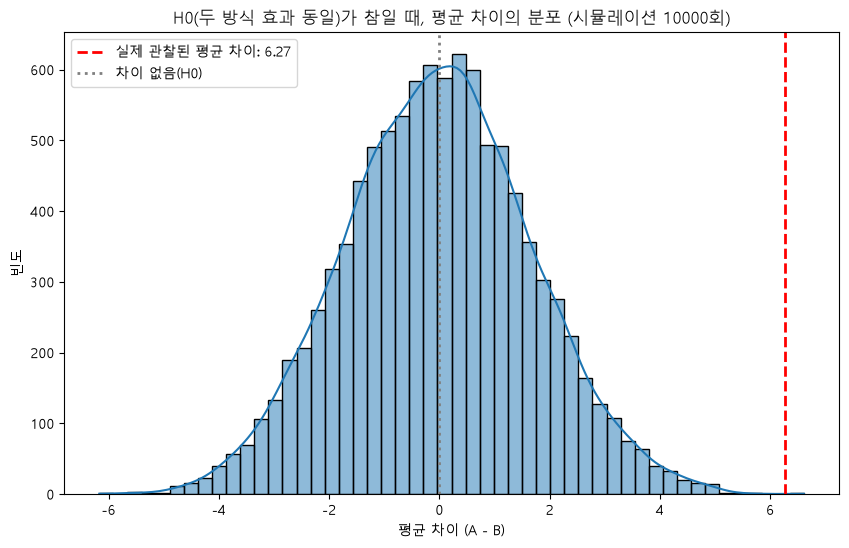

시뮬레이션 기반 p-value: 0.0001
Welch's t-검정 p-value: 0.0001


In [25]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.
observed_diff = group_a_scores.mean() - group_b_scores.mean()

plt.figure(figsize=(10, 6))
sns.histplot(simulated_diffs, bins=50, kde=True)
plt.axvline(x=observed_diff, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 평균 차이: {observed_diff:.2f}')
plt.axvline(x=0, color='gray', linestyle=':', linewidth=2, label='차이 없음(H0)')
plt.title(f'H0(두 방식 효과 동일)가 참일 때, 평균 차이의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('평균 차이 (A - B)')
plt.ylabel('빈도')
plt.legend()
plt.show()

# 시뮬레이션 기반 p-value (양측)
sim_p_value = np.mean(np.abs(simulated_diffs) >= np.abs(observed_diff))
print(f"시뮬레이션 기반 p-value: {sim_p_value:.4f}")
print(f"Welch's t-검정 p-value: {p_value:.4f}")

**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요? -> 귀무는 모두 가정을 따른다. 이고 대립은 따르지 않늗다.이다. 결과를 봤을 때, 정규성은 둘 다 만족하지만 등분산성은 만족하지 않는것으로 나옴. 따라서 독립이표본t-test는 쓸 수 없고 다른 검정방법을 써야한다. 

- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요? -> 귀무가설이 학습방식 A와 B를 학생들에게 적용했을때 그 '차이'가 없다를 의미하기 때문이다. 

- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요? -> 벗어납니다(희귀하다는 뜻, 귀무가설을 기각해야한다는 뜻)

- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요? -> 세로선 바깥 영역의 넓이가 매우 작아보인다. 즉, p값이 유의수준보다 훨씬 작을 것 같고, 그래서 귀무가설을 기각할 것이다. 

- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요? -> A학습방식을 적용했을 때 점수가 더 유의하게 높다는 뜻이기 때문에 A방식을 다른 교육 기관들에도 적용시키도록 활용하면, 기존보다 학생들의 학습에 더 좋은 효과를 줄 수 있을 것이다. 

In [ ]:
# [문제 3] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

[1번 문제]
- 정규성 검정(Shapiro-Wilk)은 A, B 두 그룹 모두 p-value가 유의수준(0.05)보다 커서 귀무가설(정규분포를 따른다)을 기각하지 못했다. 즉 두 그룹 다 정규성 가정은 만족한다.
- 등분산성 검정(Levene's test)은 p-value가 0.05보다 작게 나와서 귀무가설(두 그룹의 분산은 같다)을 기각했다. 즉 두 그룹의 분산이 서로 다르다.
- 이 결과가 의미하는 건, 일반적인(Student's) 이표본 t-검정은 등분산 가정을 전제로 하기 때문에 그대로 쓰기엔 무리가 있다는 것이다. 다만 여기서 짚고 넘어갈 부분: 그렇다고 "이표본 t-검정 자체를 쓸 수 없다"는 아니고, 이표본 t-검정의 변형인 Welch's t-test(equal_var=False)를 쓰면 된다. Welch's t-test는 등분산을 가정하지 않고도 두 그룹의 평균을 비교할 수 있도록 자유도를 보정한 방식이라, 완전히 다른 검정법으로 갈아타는 게 아니라 같은 t-검정 계열 안에서 적절한 버전을 선택하는 것이다.

[2번 문제]
- 이 히스토그램은 귀무가설(두 학습 방식의 효과가 같다, 즉 평균 차이 = 0)이 참이라는 가정 하에 라벨을 무작위로 섞어 시뮬레이션한 결과다. "차이가 없다"는 가정 자체를 전제로 만든 분포이기 때문에, 우연히 계산되는 평균 차이들은 0을 중심으로 좌우 대칭에 가깝게 퍼지는 것이 자연스럽다.

[3번 문제]
- 벗어난다. 세로선(6.27)은 시뮬레이션 분포의 오른쪽 끝, 거의 값이 존재하지 않는 꼬리 부분에 위치한다. 즉 "두 방식의 효과가 같다"는 가정 하에서는 우연히 나오기 매우 어려운 극단적인 값이므로, 귀무가설을 기각할 근거가 된다.

[4번 문제]
- 관계가 있다. p-값은 "관찰된 값 또는 그보다 더 극단적인 값이 나올 확률"인데, 그래프에서 세로선 바깥쪽(꼬리 방향) 영역의 면적 비율이 곧 p-값에 해당한다. 지금처럼 세로선이 분포 끝에 걸쳐 있고 그 바깥 영역이 육안으로 거의 안 보일 정도로 작다면, p-값도 유의수준(0.05)보다 훨씬 작다는 뜻이다. 실제로 Welch's t-test의 p-value도 이와 일치하는 매우 작은 값으로 나온다.

[5번 문제]
- A 학습 방식이 B보다 유의미하게 더 높은 점수를 낸다는 통계적 근거가 확보되었으므로, 교육 기업은 A 방식을 표준 교육 방식으로 채택하거나 다른 강의/기관으로 확대 적용하는 근거 자료로 활용할 수 있다. 다만 이번 실험은 각 그룹 50명 규모의 표본이므로, 확대 적용 전에 더 다양한 학생군·과목에서 반복 검증하거나, 효과 크기(effect size)까지 함께 확인해 실질적인 개선 폭이 충분한지도 점검하는 게 좋다.

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

관측 빈도 (Observed Frequencies):
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60


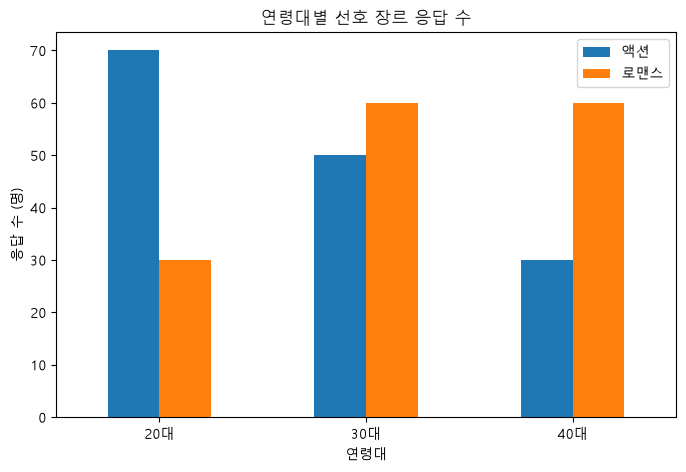

In [47]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [ ]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 연령대와 선호 장르는 서로 독립이다 (관련이 없다).
# H₁ (대립가설): 연령대와 선호 장르는 서로 독립이 아니다 (관련이 있다).

In [60]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

print("=== 관측 빈도 ===")
print(observed)
print("\n=== 기대 빈도 (독립일 때 기대되는 값) ===")
print(expected_df.round(2))

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")
print(f"p-value: {p_value:.8f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np-value({p_value:.8f}) < 유의수준({alpha}) → 귀무가설 기각")
    print("→ 연령대와 선호 장르는 서로 독립이 아니다 (연관이 있다).")
else:
    print(f"\np-value({p_value:.8f}) >= 유의수준({alpha}) → 귀무가설 기각 못함")
    print("→ 연령대와 선호 장르가 독립이 아니라고 볼 증거가 부족하다.")

=== 관측 빈도 ===
     액션  로맨스
20대  70   30
30대  50   60
40대  30   60

=== 기대 빈도 (독립일 때 기대되는 값) ===
       액션   로맨스
20대  50.0  50.0
30대  55.0  55.0
40대  45.0  45.0

카이제곱 통계량: 26.9091
자유도: 2
p-value: 0.00000143

p-value(0.00000143) < 유의수준(0.05) → 귀무가설 기각
→ 연령대와 선호 장르는 서로 독립이 아니다 (연관이 있다).


In [ ]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
np.random.seed(2026)
n_simulations = 5000
n_total = observed.values.sum()  # 300명

# 힌트1: 전체 비율 (주변확률) 계산
age_groups = observed.index.tolist()      # ['20대', '30대', '40대']
genres = observed.columns.tolist()        # ['액션', '로맨스']

age_probs = (observed.sum(axis=1) / n_total).values     # 연령대별 비율
genre_probs = (observed.sum(axis=0) / n_total).values   # 장르별 비율

simulated_chi2 = []

for _ in range(n_simulations):
    # 힌트2: 독립적으로(서로 무관하게) 300명의 연령대와 장르를 각각 뽑기
    fake_ages = np.random.choice(age_groups, size=n_total, p=age_probs)
    fake_genres = np.random.choice(genres, size=n_total, p=genre_probs)

    # 힌트3: 분할표 생성 후 카이제곱 통계량 계산
    fake_table = pd.crosstab(fake_ages, fake_genres)
    fake_chi2, _, _, _ = stats.chi2_contingency(fake_table)
    simulated_chi2.append(fake_chi2)

simulated_chi2 = np.array(simulated_chi2)

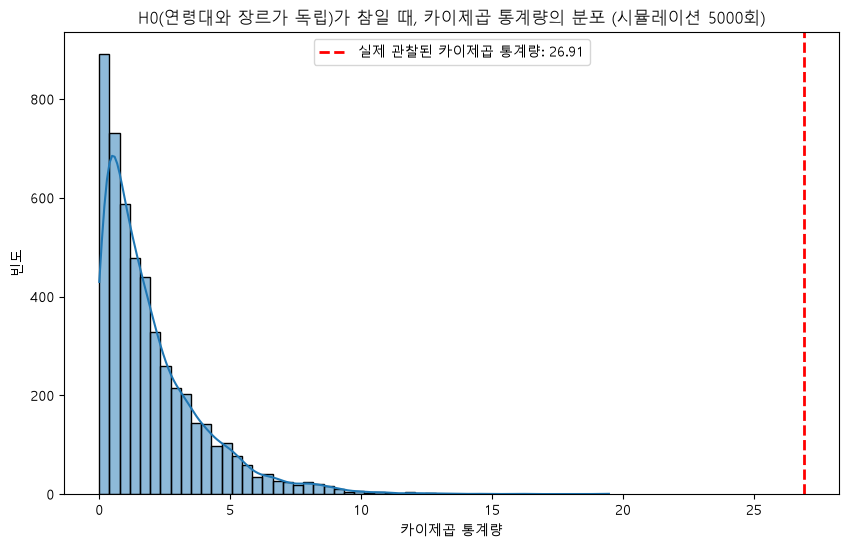

In [ ]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.
plt.figure(figsize=(10, 6))
sns.histplot(simulated_chi2, bins=50, kde=True)
plt.axvline(x=chi2_stat, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 카이제곱 통계량: {chi2_stat:.2f}')
plt.title(f'H0(연령대와 장르가 독립)가 참일 때, 카이제곱 통계량의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('카이제곱 통계량')
plt.ylabel('빈도')
plt.legend()
plt.show()

# 시뮬레이션 기반 p-value
sim_p_value = np.mean(simulated_chi2 >= chi2_stat)
print(f"시뮬레이션 기반 p-value: {sim_p_value:.4f}")
print(f"카이제곱 검정 p-value: {p_value:.4f}")

임계값(critical value, dof=2): 5.9915


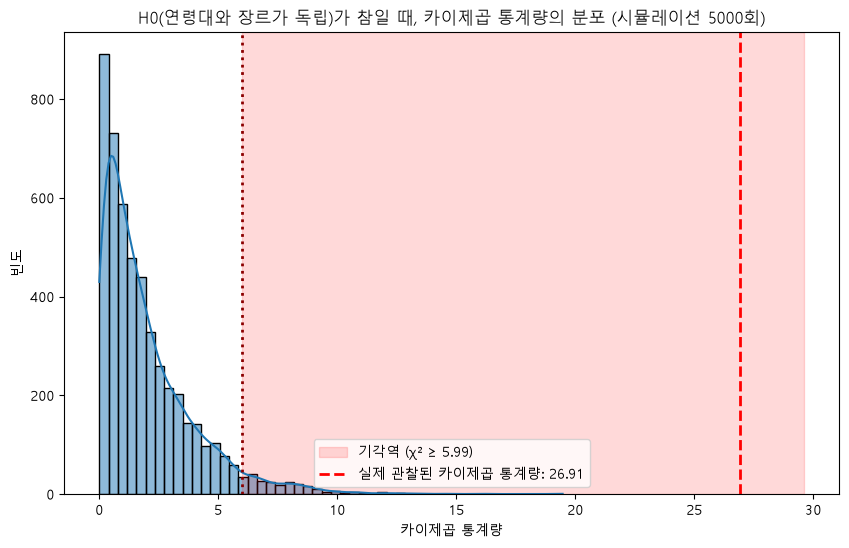


관찰된 카이제곱 통계량(26.9091)이 기각역 안에 속함


In [58]:
# 기각역 계산 (카이제곱 검정은 오른쪽 꼬리 단측검정)
alpha = 0.05
critical_value = stats.chi2.ppf(1 - alpha, dof)
print(f"임계값(critical value, dof={dof}): {critical_value:.4f}")

# 기각역 오른쪽 끝 = 시뮬레이션 최댓값과 관찰값 중 더 큰 쪽 기준
x_max = max(simulated_chi2.max(), chi2_stat) * 1.1

plt.figure(figsize=(10, 6))
sns.histplot(simulated_chi2, bins=50, kde=True)

# 기각역 음영 표시 (임계값보다 큰 오른쪽 영역)
plt.axvspan(critical_value, x_max, color='red', alpha=0.15,
            label=f'기각역 (χ² ≥ {critical_value:.2f})')

# 임계값 경계선
plt.axvline(x=critical_value, color='darkred', linestyle=':', linewidth=2)

# 관찰된 카이제곱 통계량
plt.axvline(x=chi2_stat, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 카이제곱 통계량: {chi2_stat:.2f}')

plt.title(f'H0(연령대와 장르가 독립)가 참일 때, 카이제곱 통계량의 분포 (시뮬레이션 {n_simulations}회)')
plt.xlabel('카이제곱 통계량')
plt.ylabel('빈도')
plt.legend()
plt.show()

print(f"\n관찰된 카이제곱 통계량({chi2_stat:.4f})이 기각역 안에 "
      f"{'속함' if chi2_stat >= critical_value else '속하지 않음'}")

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요? -> 두 변수가 독립이라는 가정 하에 나올 이론적인 빈도수 , 클수록 카이제곱 통계량은 커진다. 

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요? -> 카이제곱분포를 시각화했다. 독립이라는 가정 아래에서는 흔하지 않은 값, 즉 극단적인 값이다. 

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요? -> 연관성이 있다. p가 너무 작잖아ㅏ

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

[1번 문제]
- 기대 빈도는 "만약 연령대와 선호 장르가 정말 서로 독립(아무 관련 없음)이라면, 이론적으로 나와야 할 빈도"를 뜻한다. 예를 들어 20대-액션 칸의 기대 빈도(50.0)는, 전체 액션/로맨스 비율과 연령대 비율만 가지고 계산한 "우연히 예상되는 값"이다.

- 관측 빈도(실제 데이터)와 기대 빈도(독립 가정 시 이론값)의 차이가 클수록, 카이제곱 통계량은 커진다. 카이제곱 통계량 자체가 (관측-기대)²/기대 값들을 모두 더한 것이기 때문에, 두 값의 괴리가 클수록 "독립이라는 가정과 실제 데이터가 안 맞는다"는 신호가 강해지는 것이다.

[2번 문제]
- 이 히스토그램은 "연령대와 선호 장르가 독립이다"라는 귀무가설이 참이라고 가정했을 때, 300명을 무작위로 반복 추출하여 나올 수 있는 카이제곱 통계량들의 분포(카이제곱 분포에 대한 시뮬레이션 근사)를 나타낸다.

- 실제 관찰된 카이제곱 통계량(26.91)은 매우 극단적인 값이다. 분포 대부분이 0~10 사이에 몰려 있는데, 관찰값은 그 범위를 훨씬 벗어난 오른쪽 끝에 위치해 있다. 즉 두 변수가 독립이라면 이런 값이 나오는 건 거의 불가능에 가깝다.

- 그래프에서 색칠이 오른쪽에만 있는 이유: 카이제곱 통계량은 (관측-기대)²을 더하는 구조라 항상 0 이상이고, 값이 클수록 "독립 가정과 실제 데이터가 안 맞는다"는 뜻이다. 즉 통계량이 작으면 작을수록 독립 가정과 잘 맞는 거고, 크면 클수록 독립 가정에서 벗어난 증거가 된다 — 방향이 한쪽(큰 값 쪽)으로만 존재하는 것이다. 그래서 왼쪽 꼬리는 애초에 "기각할 이유"가 되지 않고, 기각역은 오른쪽 꼬리 하나만 있는 단측검정 구조가 되는 것이다.

[3번 문제]
- 있다. p-value(0.00000143)가 유의수준 0.05보다 훨씬 작기 때문에 귀무가설(독립이다)을 기각한다. 즉 연령대와 선호 장르 사이에는 우연이라고 보기 어려운, 통계적으로 유의미한 연관성이 존재한다.

[4번 문제]
- 관측 빈도를 보면 20대는 액션(70명)을 로맨스(30명)보다 훨씬 선호하고, 40대는 반대로 로맨스(60명)를 액션(30명)보다 선호하는 뚜렷한 경향이 있다. 30대는 두 장르 선호도가 비슷하다(50 vs 60).

- 이를 바탕으로 영화관은 연령대 타겟 마케팅을 할 수 있다. 예를 들어 액션 영화 개봉 시 20대가 몰리는 시간대(저녁·주말 등)에 20대 대상 프로모션(학생 할인, SNS 이벤트 등)을 집중하고, 로맨스 영화 개봉 시에는 40대 대상 프로모션(가족 단위 할인, 평일 낮 시간대 회차 확대 등)을 강화하는 식으로 상영관 배정과 광고 채널을 세분화할 수 있다.


In [ ]:
# [문제 4] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

In [ ]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [ ]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?

- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?

In [ ]:
# [문제 5] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.